# Anchored Langevin on a non-differentiable target

Titanic and MAGIC, accuracy **and** predictive log-loss, for three skew-symmetric fields.

## The target, the anchor, the clock

Replacing the Gaussian prior with a Laplace one puts a kink at every $w_j = 0$:

$$U(w) \;=\; \underbrace{\sum_i \Big[\log\big(1 + e^{x_i \cdot w}\big) - y_i\,(x_i \cdot w)\Big]}_{U_\text{nll}(w)} \;+\; \lambda \lVert w \rVert_1 ,$$

with $\lambda = 5$ (Laplace scale $0.2$) and the intercept left unpenalised. A
central-difference surrogate cannot describe this: differencing $|w|$ with step $\epsilon$
returns $\mathrm{clip}(w/\epsilon, -1, 1)$, the gradient of an $\epsilon$-Huber smoothing, so a
chain driven by it targets the wrong law however small the step size gets.

The **anchor** replaces the kink with a smooth majorant of it, and the **clock** is the
exponential of the gap they leave:

$$U_0(w) = U_\text{nll}(w) + \lambda \sum_{j \ge 1} \sqrt{w_j^2 + \delta^2},
\qquad a(w) = e^{U(w) - U_0(w)} \in \big[e^{-\lambda (d-1)\delta},\, 1\big].$$

$U_0$ is smooth, $U \le U_0$, and the likelihood cancels in $U - U_0$, so the clock is
$O(d)$ arithmetic on the penalties and never touches the data.

## The dynamics

Anchored Langevin ([Gürbüzbalaban, Hu, Yuan and Zhu, arXiv:2509.19455](https://arxiv.org/abs/2509.19455))
follows the gradient of the *anchor* and scales the diffusion by the clock,

$$dw = -a(w)\,\nabla U_0(w)\,dt + \sqrt{2 a(w)}\,dB ,$$

and $e^{-U}$ is exactly invariant. The quickest way to see it is the random time change:
the anchored process is the $U_0$-diffusion run on a state-dependent clock of rate $a$, and
time-changing a diffusion whose invariant density is $p$ at rate $a$ leaves invariant density
proportional to $p/a$, here $e^{-U_0}/e^{U - U_0} = e^{-U}$.

The same argument composes with an irreversible drift, which is the reason these two ideas
belong together. The irreversible $U_0$-diffusion
$dy = [-(I + J)\nabla U_0 + \nabla\!\cdot\!J]\,dt + \sqrt 2\,dB$ has invariant density
$e^{-U_0}$, so time-changing *it* at rate $a$ gives

$$dw = a(w)\Big[-(I + J(w))\,\hat g_0(w) + (\nabla\!\cdot\!J)(w)\Big] dt + \sqrt{2 a(w)}\,dB$$

with invariant density $e^{-U}$ for **any** skew $J$. The $\ell_1$ term never enters a
gradient: it appears only inside the scalar clock, which is an evaluation. $\hat g_0$ is the
central-difference surrogate of $\nabla U_0$, and differencing the anchor is meaningful
precisely because the anchor is smooth.

## What is compared

| field | drift inside the brackets |
|---|---|
| $J = 0$ | $-\hat g_0$ |
| constant $J_a$ | $-(I + J_a)\hat g_0$, $J_a$ designed from the warm-up Hessian of $U_0$ |
| state-dependent $J_s$ | the same design behind a gate on the posterior bulk, plus $\nabla\!\cdot\!J_s$ |

The reference cannot be the gradient-based MALA used for the smooth targets in this
repository. It is **random-walk Metropolis on $U$ itself**: no gradients, no smoothing, exact
whatever the kink does. Runtime for this notebook is about ten minutes with the cached
references, mostly MAGIC's warm-up.

In [1]:
import json, os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from nds.anchored import LassoLogistic, reference_posterior_rwm, run_anchored_chain
from nds.data import PRETTY_NAMES, load
from nds.design import calibrate_amplitude, explicit_step_size, paired_skew
from nds.metrics import iterations_to_reach
from nds.sampler import Geometry, warm_up
from nds.skew import ConstantSkew, GatedSkew, ZeroSkew
from nds.target import _sigmoid

DATASETS = ["titanic", "magic"]
PENALTY, DELTA = 5.0, 0.02      # lambda of the L1 penalty, anchor smoothing
N_ITER, N_WALKERS = 200, 24
SAFETY = 0.15                   # step size is 2 * SAFETY / max Re mu
AMPLITUDES = (0.0, 0.5, 1.0)    # rotation amplitudes the calibration tries
GATE_FRACTION, GATE_WIDTH = 0.75, 0.1
WARMUP = dict(n_iter=200, n_walkers=8, n_rounds=2, shrinkage=0.05)
SEED = 0
RESULTS = os.path.abspath(os.path.join("..", "results"))
print("numpy", np.__version__)

numpy 2.4.6


## 1. The target and its anchor

Three things worth seeing before sampling: the anchor really does majorise the target, the
gap is bounded so the clock cannot collapse, and the anchor's difference quotient agrees
with its true gradient. The last one is what the whole construction rests on.

In [2]:
data = {name: load(name, seed=0) for name in DATASETS}
targets = {name: LassoLogistic(ds.X_train, ds.y_train, penalty=PENALTY, delta=DELTA)
           for name, ds in data.items()}

rows = []
rng = np.random.default_rng(1)
for name, target in targets.items():
    W = np.column_stack([np.zeros(target.d), rng.normal(size=target.d) * 0.5])
    U, U0 = target.potential(W), target.anchor_potential(W)
    Z = target.linear(W)
    exact = target.X.T @ (_sigmoid(Z) - target.y[:, None]) + target.weights * W / np.sqrt(
        W**2 + target.delta**2)
    fd = target.anchor_fd_grad(W, eps=1e-3)
    rows.append({
        "dataset": PRETTY_NAMES[name],
        "d": target.d,
        "U(0)": round(float(U[0]), 1),
        "U_0(0)": round(float(U0[0]), 1),
        "max U - U_0": round(float((U - U0).max()), 4),
        "clock at 0": round(float(target.clock(W)[0, 0]), 4),
        "clock floor": round(target.clock_floor, 4),
        "anchor grad: fd vs exact": f"{np.abs(fd - exact).max() / np.abs(exact).max():.1e}",
    })
pd.DataFrame(rows).set_index("dataset").T

dataset,Titanic (survival),MAGIC Gamma Telescope
d,10,11
U(0),431.8,9228.6
U_0(0),432.7,9229.6
max U - U_0,-0.0361,-0.1664
clock at 0,0.4066,0.3679
clock floor,0.4066,0.3679
anchor grad: fd vs exact,1.5e-07,3.9e-07


## 2. Reference posterior: random-walk Metropolis on `U`

The accept/reject step makes `exp(-U)` exactly invariant however rough `U` is, which is what
the anchored chain has to be measured against. Cached runs from the repository are reused;
computing one takes about twenty seconds on Titanic and four minutes on MAGIC.

In [3]:
def get_reference(name, ds, target):
    path = os.path.join(RESULTS, f"reference_lasso_{name}_p{PENALTY:g}.npz")
    if os.path.exists(path):
        blob = np.load(path)
        return {k: blob[k] for k in blob.files}
    ref = reference_posterior_rwm(target, ds.X_test, ds.y_test, n_iter=100000,
                                  n_warmup=20000, n_chains=8, seed=SEED)
    return ref


references = {}
for name, ds in data.items():
    ref = get_reference(name, ds, targets[name])
    references[name] = {
        "accuracy": float(ref["accuracy"]),
        "loss": float(ref["loss"]),
        "accuracy_halves": np.atleast_1d(ref["accuracy_halves"]).tolist(),
        "loss_halves": np.atleast_1d(ref["loss_halves"]).tolist(),
        "mean": ref["posterior_mean"],
        "cov": ref["posterior_cov"],
    }

pd.DataFrame([
    {"dataset": PRETTY_NAMES[n],
     "reference accuracy": round(r["accuracy"], 4),
     "accuracy halves": [round(v, 4) for v in r["accuracy_halves"]],
     "reference log-loss": round(r["loss"], 4),
     "loss halves": [round(v, 4) for v in r["loss_halves"]],
     "||w||_1 of the mean": round(float(np.abs(r["mean"][1:]).sum()), 3)}
    for n, r in references.items()
])

,dataset,reference accuracy,accuracy halves,reference log-loss,loss halves,||w||_1 of the mean
0,Titanic (survival),0.7724,"[0.7761, 0.7724]",0.4608,"[0.4608, 0.4608]",3.286
1,MAGIC Gamma Telescope,0.7950,"[0.795, 0.795]",0.4586,"[0.4586, 0.4586]",3.799


## 3. Warm-up and the design

The warm-up runs Metropolis on the true, non-differentiable `U`, so it is exact however
rough the difference-quotient drift is, and returns an estimate of the posterior covariance
$\hat\Sigma$ and mean $\hat m$. Writing $\hat H = \hat\Sigma^{-1}$, `paired_skew` couples the
$k$-th slowest eigendirection of $\hat H$ to the $k$-th fastest at the amplitude where the
pair's two relaxation rates collide at their mean. That is the most a skew term can do:
$\operatorname{tr}\big((D + J)\hat H\big)$ does not depend on $J$, so rate bought for the slow
directions is sold from the fast ones, and the collision amplitude repays it by halving the
spectral radius of the drift, which doubles the step size the same rule allows.

The amplitude is calibrated by a short pilot **of the anchored chain itself**, scored by how
fast the ensemble reaches the target spread along the slowest directions. Nothing in this
step uses a gradient of `U`, the held-out labels, or the reference.

In [4]:
designs = {}
for name, ds in data.items():
    t0 = time.time()
    target = targets[name]
    pilot = warm_up(target, seed=SEED, **WARMUP)
    H_hat, m_hat = pilot["geometry"].D_inv, pilot["mean_state"]
    identity = Geometry.identity(target.d)
    r0 = float(np.sqrt(max(m_hat @ (H_hat @ m_hat), 1e-12)))

    def make_constant(amplitude, H=H_hat):
        J, _ = paired_skew(H, amplitude=amplitude)
        return ConstantSkew(J, 1.0), J

    def make_gated(amplitude, drop=False, H=H_hat, m=m_hat, radius=r0):
        J, _ = paired_skew(H, amplitude=amplitude)
        field = GatedSkew(J, 1.0, radius=GATE_FRACTION * radius, width=GATE_WIDTH * radius,
                          metric=H, center=m, drop_correction=drop)
        return field, J

    amps, reports = {}, {}
    for key, factory in (("constant", make_constant), ("state", make_gated)):
        cal = calibrate_amplitude(target, H_hat, m_hat, make_field=factory,
                                  amplitudes=AMPLITUDES, safety=SAFETY, n_iter=150,
                                  n_walkers=16, seed=SEED, runner=run_anchored_chain)
        amps[key] = cal["amplitude"]
        _, J = factory(cal["amplitude"])
        reports[key] = paired_skew(H_hat, amplitude=cal["amplitude"])[1]
        reports[key]["step_size"] = explicit_step_size(H_hat, J, safety=SAFETY)
        reports[key]["ladder"] = cal["ladder"]

    designs[name] = {
        "geometry": identity,
        "H": H_hat,
        "amplitudes": amps,
        "reports": reports,
        "fields": {
            "zero": ZeroSkew(),
            "constant": make_constant(amps["constant"])[0],
            "state": make_gated(amps["state"])[0],
        },
        "steps": {
            "zero": explicit_step_size(H_hat, None, safety=SAFETY),
            "constant": reports["constant"]["step_size"],
            "state": reports["state"]["step_size"],
        },
        "seconds": time.time() - t0,
    }
    print(f"{name}: warm-up and calibration in {designs[name]['seconds']:.0f}s, "
          f"amplitudes {amps}")

titanic: warm-up and calibration in 9s, amplitudes {'constant': 1.0, 'state': 1.0}


magic: warm-up and calibration in 192s, amplitudes {'constant': 1.0, 'state': 1.0}


In [5]:
pd.DataFrame([
    {
        "dataset": PRETTY_NAMES[name],
        "cond(H) of the anchor": round(dz["reports"]["state"]["condition_number"], 1),
        "slowest rate, J = 0": round(dz["reports"]["state"]["reversible_rate"], 3),
        "slowest rate, designed": round(dz["reports"]["state"]["irreversible_rate"], 3),
        "best possible (mean rate)": round(dz["reports"]["state"]["mean_rate_bound"], 3),
        "amplitude, constant": dz["amplitudes"]["constant"],
        "amplitude, gated": dz["amplitudes"]["state"],
        "h, J = 0": f"{dz['steps']['zero']:.3g}",
        "h, designed / h, J = 0": round(dz["steps"]["state"] / dz["steps"]["zero"], 2),
    }
    for name, dz in designs.items()
]).set_index("dataset").T

dataset,Titanic (survival),MAGIC Gamma Telescope
cond(H) of the anchor,9.6,47.6
"slowest rate, J = 0",19.0,73.567
"slowest rate, designed",82.599,998.09
best possible (mean rate),89.281,1259.147
"amplitude, constant",1.0,1.0
"amplitude, gated",1.0,1.0
"h, J = 0",0.00164,8.57e-05
"h, designed / h, J = 0",1.81,1.96


## 4. Run the three fields

Same walker seeds for every field, so the curves differ only by the drift. `mean clock` is
the average of `a` along the trajectory: one minus that is the price the exactness costs in
effective step size.

In [6]:
runs = {}
for name, ds in data.items():
    dz, target = designs[name], targets[name]
    ref_metric = np.linalg.pinv(references[name]["cov"])
    runs[name] = {}
    for key, field in dz["fields"].items():
        res = run_anchored_chain(
            target, field, dz["steps"][key], N_ITER, n_walkers=N_WALKERS, seed=SEED + 101,
            X_eval=ds.X_test, y_eval=ds.y_test, geometry=dz["geometry"], scheme="anchored",
            ref_mean=references[name]["mean"], ref_metric=ref_metric,
        )
        runs[name][key] = {
            "step_size": dz["steps"][key],
            "accuracy": res.accuracy.mean(axis=1),
            "loss": res.loss.mean(axis=1),
            "error": res.mean_error.mean(axis=1),
            "clock": res.meta["mean_clock"],
            "l1_of_mean": float(np.abs(res.posterior_mean.mean(axis=1)[1:]).sum()),
        }
        print(f"{name:8s} {key:9s} h={dz['steps'][key]:.4g} clock={res.meta['mean_clock']:.3f} "
              f"accuracy {res.accuracy[-1].mean():.4f}  log-loss {res.loss[-1].mean():.4f}")

titanic  zero      h=0.001641 clock=0.916 accuracy 0.7774  log-loss 0.4628


titanic  constant  h=0.002973 clock=0.919 accuracy 0.7774  log-loss 0.4616


titanic  state     h=0.002973 clock=0.919 accuracy 0.7767  log-loss 0.4618


magic    zero      h=8.569e-05 clock=0.872 accuracy 0.7937  log-loss 0.4593


magic    constant  h=0.0001679 clock=0.847 accuracy 0.7939  log-loss 0.4585


magic    state     h=0.0001679 clock=0.845 accuracy 0.7939  log-loss 0.4585


## 5. Accuracy and loss

Left column accuracy, right column log-loss, one row per dataset. The dashed line is the
random-walk-Metropolis reference on the same test set, the grey band a tolerance around it
(`+/- 0.005` for accuracy, `+/- 1%` for loss). The y-axes skip the first two iterations,
where every curve leaves the `w = 0` values 0.5 and `log 2`.

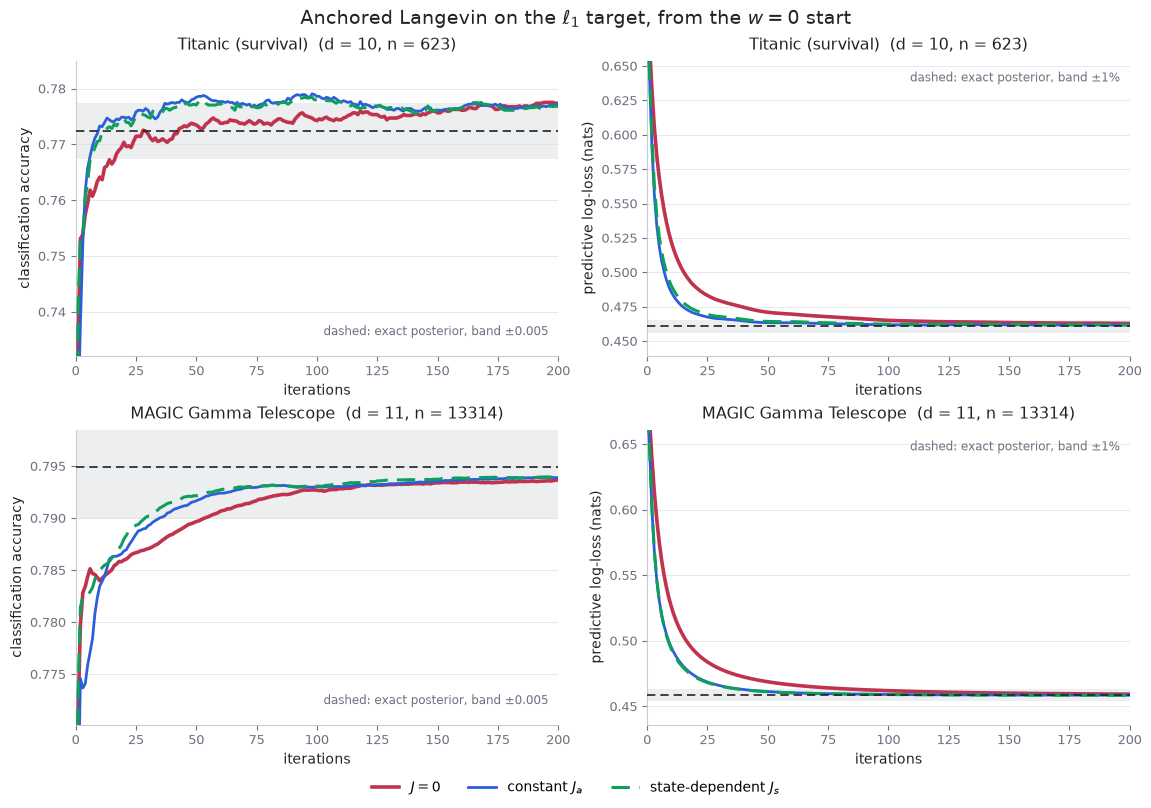

In [7]:
PALETTE = {
    "zero": ("#C0334D", "-", 2.6, r"$J = 0$"),
    "constant": ("#2B5FD9", "-", 2.0, r"constant $J_a$"),
    "state": ("#0E9F5C", (0, (6, 3)), 2.2, r"state-dependent $J_s$"),
}
INK, MUTED = "#1f2328", "#6b7280"


def style_axes(ax):
    ax.grid(True, axis="y", color="#d8dade", lw=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c7cad0")
    ax.tick_params(colors=MUTED, labelsize=9)


fig, axes = plt.subplots(len(DATASETS), 2, figsize=(11.4, 4.0 * len(DATASETS)),
                         squeeze=False, layout="constrained")
iters = np.arange(N_ITER + 1)

for row, name in enumerate(DATASETS):
    for col, (metric, label) in enumerate([("accuracy", "classification accuracy"),
                                           ("loss", "predictive log-loss (nats)")]):
        ax = axes[row][col]
        style_axes(ax)
        ref = references[name]["accuracy"] if metric == "accuracy" else references[name]["loss"]
        band = 0.005 if metric == "accuracy" else 0.01 * ref
        ax.axhspan(ref - band, ref + band, color="#d8dade", alpha=0.45, lw=0, zorder=1)
        ax.axhline(ref, color=INK, ls=(0, (5, 3)), lw=1.2, zorder=7)
        flat = []
        for key, (color, ls, lw, legend) in PALETTE.items():
            curve = runs[name][key][metric]
            flat.append(curve[2:])
            ax.plot(iters, curve, color=color, ls=ls, lw=lw, label=legend, zorder=4)
        flat = np.concatenate(flat + [[ref]])
        pad = 0.12 * (flat.max() - flat.min()) + 1e-3
        ax.set_ylim(flat.min() - pad, flat.max() + pad)
        ax.set_xlim(0, N_ITER)
        ax.set_xlabel("iterations", color=INK, fontsize=10)
        ax.set_ylabel(label, color=INK, fontsize=10)
        ax.set_title(f"{PRETTY_NAMES[name]}  (d = {data[name].dim}, n = {len(data[name].y_train)})",
                     color=INK, fontsize=11.5, pad=8)
        note = ("dashed: exact posterior, band $\\pm$0.005" if metric == "accuracy"
                else "dashed: exact posterior, band $\\pm$1%")
        y, va = (0.06, "bottom") if metric == "accuracy" else (0.96, "top")
        ax.annotate(note, xy=(0.98, y), xycoords="axes fraction", ha="right", va=va,
                    fontsize=8.5, color=MUTED)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3, frameon=False, fontsize=10)
fig.suptitle("Anchored Langevin on the $\\ell_1$ target, from the $w = 0$ start",
             fontsize=14, color=INK)
os.makedirs(os.path.join("..", "figures"), exist_ok=True)
fig.savefig(os.path.join("..", "figures", "notebook_anchored_l1.png"), dpi=200)
plt.show()

## 6. Numbers

`iters to band` is the first iteration from which the curve stays inside its tolerance band
for the rest of the run. `mean error` is the distance of the running posterior mean from the
reference in reference posterior standard deviations, and `||w||_1 of mean` is the functional
that actually feels the kink.

In [8]:
rows = []
for name in DATASETS:
    ref_acc, ref_loss = references[name]["accuracy"], references[name]["loss"]
    ref_l1 = float(np.abs(references[name]["mean"][1:]).sum())
    for key in PALETTE:
        run = runs[name][key]
        rows.append({
            "dataset": PRETTY_NAMES[name],
            "field": {"zero": "J = 0", "constant": "constant J_a", "state": "gated J_s"}[key],
            "amplitude": designs[name]["amplitudes"].get(key, 0.0) if key != "zero" else 0.0,
            "step size": f"{run['step_size']:.3g}",
            "mean clock": round(run["clock"], 3),
            "accuracy @200": round(float(run["accuracy"][-1]), 4),
            "iters to acc band": iterations_to_reach(run["accuracy"], ref_acc, 0.005),
            "log-loss @200": round(float(run["loss"][-1]), 4),
            "loss - ref": round(float(run["loss"][-1]) - ref_loss, 4),
            "iters to loss band": iterations_to_reach(run["loss"], ref_loss, 0.01 * ref_loss),
            "mean error @200": round(float(run["error"][-1]), 3),
            "||w||_1 of mean": round(run["l1_of_mean"], 3),
            "reference ||w||_1": round(ref_l1, 3),
        })

summary = pd.DataFrame(rows)
summary.to_csv("anchored_l1_summary.csv", index=False)
summary

,dataset,field,amplitude,step size,mean clock,accuracy @200,iters to acc band,log-loss @200,loss - ref,iters to loss band,mean error @200,||w||_1 of mean,reference ||w||_1
0,Titanic (survival),J = 0,0.0,0.00164,0.916,0.7774,199,0.4628,0.0020,97,1.039,3.142,3.286
1,Titanic (survival),constant J_a,1.0,0.00297,0.919,0.7774,166,0.4616,0.0008,37,0.629,3.234,3.286
2,Titanic (survival),gated J_s,1.0,0.00297,0.919,0.7767,169,0.4618,0.0010,42,0.633,3.228,3.286
3,MAGIC Gamma Telescope,J = 0,0.0,8.57e-05,0.872,0.7937,53,0.4593,0.0007,84,4.915,3.552,3.799
4,MAGIC Gamma Telescope,constant J_a,1.0,0.000168,0.847,0.7939,35,0.4585,-0.0001,39,1.859,3.693,3.799
5,MAGIC Gamma Telescope,gated J_s,1.0,0.000168,0.845,0.7939,29,0.4585,-0.0001,38,1.787,3.692,3.799


## 7. What the clock costs, and what it corrects

The clock is not free: the effective step is $h\,a(w)$, so a coarse anchor slows the chain in
proportion. Two long runs from the repository, both on Titanic against the same
random-walk-Metropolis reference, compare three schemes at two anchor smoothings:

* **anchored** — $-a\,\nabla U_0$, exact in continuous time;
* **anchor only** — $-\nabla U_0$ with the clock dropped, which samples $e^{-U_0}$, i.e. takes
  the smoothing as the model;
* **differences of $U$** — the derivative-free scheme applied to the kinked potential, which
  samples an $\epsilon$-Huber-smoothed law.

Run `python experiments/run_anchored_bias.py --delta 0.02 --n-iter 30000` and the same with
`--delta 0.1 --n-iter 20000` to regenerate these.

In [9]:
bias = []
for delta in (0.02, 0.1):
    path = os.path.join(RESULTS, f"bias_anchored_titanic_d{delta:g}.npz")
    if not os.path.exists(path):
        print(f"missing {path}; run experiments/run_anchored_bias.py --delta {delta:g}")
        continue
    blob = np.load(path, allow_pickle=False)
    meta = json.loads(str(blob["meta"]))
    for row in meta["rows"]:
        bias.append({
            "delta": meta["delta"],
            "iterations": meta["n_iter"],
            "scheme": {"anchored": "anchored", "anchor": "anchor only, exp(-U_0)",
                       "fd": "differences of U"}[row["scheme"]],
            "mean clock": round(row["mean_clock"], 3),
            "log-loss": round(row["loss_final"], 4),
            "||w||_1 of mean": round(row["l1_of_mean"], 3),
            "reference ||w||_1": round(meta["reference_l1_of_mean"], 3),
            "gap": round(row["l1_of_mean"] - meta["reference_l1_of_mean"], 3),
        })
pd.DataFrame(bias)

,delta,iterations,scheme,mean clock,log-loss,||w||_1 of mean,reference ||w||_1,gap
0,0.02,30000,anchored,0.924,0.4610,3.291,3.286,0.004
1,0.02,30000,"anchor only, exp(-U_0)",1.000,0.4609,3.297,3.286,0.010
2,0.02,30000,differences of U,1.000,0.4610,3.292,3.286,0.006
3,0.10,20000,anchored,0.303,0.4613,3.268,3.286,-0.019
4,0.10,20000,"anchor only, exp(-U_0)",1.000,0.4606,3.336,3.286,0.050
5,0.10,20000,differences of U,1.000,0.4610,3.289,3.286,0.003


At $\delta = 0.02$ the clock costs about 8% of the step size and the bias it removes is
smaller than the Monte Carlo error of a 30000-iteration run, so all three schemes agree. At
$\delta = 0.1$ the chain that ignores the clock is visibly wrong: it samples a posterior whose
prior is smoother and therefore shrinks less, $3.336$ against the reference $3.287$, while the
anchored chain sits at $3.268$ and runs three times slower for it. The chain that differences
$U$ directly is not badly wrong here only because its implicit smoothing ($\epsilon = 0.01$) is
finer than either anchor; its bias is set by $\epsilon$ and no step size removes it, whereas the
anchored chain is exact for **any** $\delta$. So $\delta$ is the knob: large enough that the
anchor is well conditioned, small enough that the clock does not crawl.

## 8. What to take from it

* **The non-differentiable term never enters a gradient.** It appears only in the scalar
  clock $a = e^{U - U_0}$, which is an evaluation of two potentials and, because the likelihood
  cancels, costs $O(d)$.
* **Anchored Langevin and the irreversible drift compose exactly.** One random time change
  carries the invariance of the irreversible $U_0$-diffusion onto $e^{-U}$, for any skew $J$,
  state-dependent or not.
* **The rotation helps here for the same reason it helps on the smooth target.** It removes
  the slowest direction of the anchor's Hessian as the bottleneck and the collision amplitude
  doubles the step size, so both fields reach the loss band in well under half the iterations
  the reversible baseline needs.
* **Log-loss is the metric to read.** Accuracy depends on the predictive mean only through
  which side of one half it falls on, so it saturates almost immediately and leaves a few
  thousandths to argue over.
* **Still unadjusted.** Every chain here carries the $O(h)$ bias of an explicit scheme; the
  step-size rule caps the worst-case variance inflation at 1.18. Exactness in continuous time
  is what the anchor buys, not exactness after discretisation.